<a href="https://colab.research.google.com/github/Assane-22/Codejavascript/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import matplotlib.pyplot as plt
import numpy as np


In [12]:
import torch
from torchvision import datasets, transforms
transform = transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.MNIST(
   root='./data',
   train=True,
   download=True,
   transform=transform
)
test_dataset = datasets.MNIST(
   root='./data',
   train=False,
   download=True,
   transform=transform
)
train_loader = torch.utils.data.DataLoader(
   dataset=train_dataset,
   batch_size=64,
   shuffle=True
)
test_loader = torch.utils.data.DataLoader(
   dataset=test_dataset,
   batch_size=64,
   shuffle=False
)

8
torch.Size([1, 28, 28])


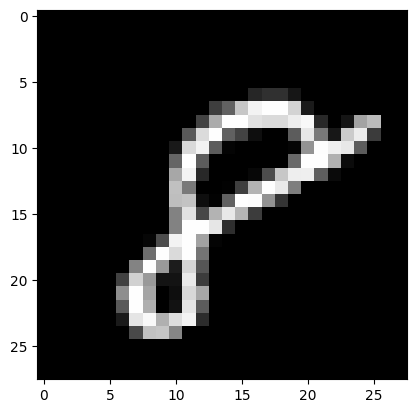

In [27]:
x1, y1 = train_loader.dataset[59999]
print(y1)
print(x1.size())
plt.imshow(x1.squeeze(), cmap='gray')

In [29]:
import torch.nn as nn
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.f1 = nn.Linear(784,256)
    self.f2 = nn.Linear(256,128)
    self.f3 = nn.Linear(128,10)
    self.a = nn.ReLU()

  def forward(self, x):
    #reshape image
    x = x.reshape(-1,784)
    a1 =self.a(self.f1(x))
    a2 = self.a(self.f2(a1))
    a3 = self.f3(a2)
    return a3

model = MLP()
print(model)

MLP(
  (f1): Linear(in_features=784, out_features=256, bias=True)
  (f2): Linear(in_features=256, out_features=128, bias=True)
  (f3): Linear(in_features=128, out_features=10, bias=True)
  (a): ReLU()
)


In [31]:
criterion = nn.CrossEntropyLoss()
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
  model.train()

  running_loss = 0.0
  correct = 0
  total = 0

  for images, labels in train_loader:

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward
    optimizer.step()

    running_loss = loss * 64
    epoch_loss.append(running_loss/60000)



NameError: name 'epoch_loss' is not defined